# **CA 2, LLMs Spring 2025**

- **Name:** Erfan Shahabi

---
#### Your submission should be named using the following format: `CA2_LASTNAME_STUDENTID.ipynb`.

---

##### *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says ```Your Answer Here``` with your actual answer.

- There is no penalty for using AI assistance on this homework as long as you fully disclose it in the final cell of this notebook (this includes storing any prompts that you feed to large language models). That said, anyone caught using AI assistance without proper disclosure will receive a zero on the assignment (we have several automatic tools to detect such cases). We're literally allowing you to use it with no limitations, so there is no reason to lie!

---

##### *Academic honesty*

- We will audit the Colab notebooks from a set number of students, chosen at random. The audits will check that the code you wrote actually generates the answers in your notebook. If you turn in correct answers on your notebook without code that actually generates those answers, we will consider this a serious case of cheating.

- We will also run automatic checks of Colab notebooks for plagiarism. Copying code from others is also considered a serious case of cheating.

---

If you have any further questions or concerns, contact the TAs via email: m.salmani78@ut.ac.ir / mehrabi.m@ut.ac.ir

## Preliminaries

In [1]:
!pip install --upgrade --force-reinstall datasets Levenshtein trl transformers bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 731.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
#import unsloth
import torch
import numpy as np
import re
import time
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from Levenshtein import ratio
from collections import defaultdict
from datasets import load_dataset
from trl import ORPOConfig, ORPOTrainer
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [3]:
import os
from huggingface_hub import login
login(token=os.getenv("HF_TOKEN"))

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `LLM1` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `LLM1`


In [4]:
class CONFIG:
    seed = 42
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model_name = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
    reward_model_name = "nicolinho/QRM-Llama3.1-8B-v2"
    benchmark_name = "openai/gsm8k"
    dataset_name = "mlabonne/orpo-dpo-mix-40k"

    train_data_size = 1600
    benchmark_subset_size = 50
    max_seq_length = 2048
    train_batch_size = 2
    gradient_accumulation_steps = 4
    epochs = 1

    # LoRA Configs
    lora_rank = 64
    lora_alpha = 64
    use_gradient_checkpointing = "unsloth"
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",]

    dpo_output_dir = "llama-3.2-3b-dpo-checkpoint"
    orpo_output_dir = "llama-3.2-3b-orpo-checkpoint"

device = CONFIG.device

### Introductions to unsloth

Modern large language models (LLMs) require significant computational resources for fine-tuning and inference. The `unsloth` library is designed to optimize these processes by making training up to 30× faster and reducing memory usage by 60%, enabling more efficient model adaptation on consumer-grade GPUs.

---

**Learn More:**

<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

### Install and Setup

In [5]:
%%capture
import os
!pip install datasets
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29 peft trl triton
    !pip install --no-deps cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [6]:
import unsloth
print(unsloth.__version__)

2025.3.19


# In-context Learning (30 Points)

### Question 1 (5 points):

**a)** What is In-Context Learning (ICL), and how does it differ from fine-tuning? What are its limitations compared to fine-tuning?

**b)** Explain what [Chain-of-Thought (CoT)](https://arxiv.org/abs/2201.11903) prompting is and how it works.

`# My Answer`
<br>
A.
<br>
In-Context Learning (ICL) allows a language model to solve tasks by simply observing a few examples in the input prompt — without modifying its internal weights. The model uses patterns it learned during pretraining to make predictions based on that temporary context.

Fine-tuning, in contrast, updates the model’s parameters through additional training on labeled, task-specific data. This leads to deeper adaptation and better performance on the given task.

**Key differences:**

- **Training:** ICL doesn’t require any additional training, while fine-tuning does.
- **Flexibility:** ICL can quickly adapt to many tasks by changing the prompt. Fine-tuning produces a model specialized for one task.
- **Performance:** Fine-tuned models often outperform ICL on complex or high-stakes tasks.

**Limitations of ICL:**

- Lower accuracy on complex or multi-step tasks.
- Very sensitive to how prompts are written.
- Limited by the model's context window (how much input it can "remember").
<br>
--------------------------------------
<br>
B.
<br>

Chain-of-Thought (CoT) prompting is a technique that guides the model to solve problems step-by-step instead of jumping straight to the final answer.

A CoT prompt might include a phrase like “Let’s solve this step by step,” which nudges the model to produce intermediate reasoning steps. These steps help both the model and the user better understand how the answer was reached.

CoT is especially useful for multi-step reasoning problems like math or logic puzzles. It improves accuracy and also makes the model’s thinking more interpretable.

### Load Model & Tokenizer (2.5 points)

- Load `Llama-3.2-3B-Instruct-bnb-4bit` model using `unsloth` for inference.

In [ ]:

from unsloth import FastLanguageModel

def load_model_and_tokenizer(model_id, max_seq_length):
    print("Loading model and tokenizer using unsloth...")
    # WRITE YOUR CODE HERE
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = model_id,
        max_seq_length = max_seq_length,
        dtype = None,
        load_in_4bit = True,
    )
    return model, tokenizer


In [ ]:
model, tokenizer = load_model_and_tokenizer(CONFIG.model_name, CONFIG.max_seq_length)

Loading model and tokenizer using unsloth...
==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

### Load benchmark (2.5 points)

1. Load the `GSM8K` benchmark dataset.
2. Randomly select a subset of `50` samples from the dataset.
3. Display one sample from the selected subset.
<a id="gsm8k_benchmark"></a>

In [7]:
def load_gsm8k_dataset():
    """Load the GSM8K dataset from HuggingFace."""
    # WRITE YOUR CODE HERE
    dataset = load_dataset("openai/gsm8k", "main", split="test")
    return dataset

def create_sample_dataset(dataset, num_samples, seed):
    """Create a fixed sample dataset for evaluation."""
    # WRITE YOUR CODE HERE
    sample_test = dataset.shuffle(seed=seed).select(range(num_samples))
    return sample_test

In [8]:
# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load dataset
dataset = load_gsm8k_dataset()

# Select subset
sample_dataset = create_sample_dataset(dataset, num_samples=CONFIG.benchmark_subset_size, seed=CONFIG.seed)

# WRITE YOUR CODE HERE
# Display one sample
sample = sample_dataset[1]
print("Question:", sample["question"])
print("Answer:", sample["answer"])

Question: Lorraine and Colleen are trading stickers for buttons. Each large sticker is worth a large button or three small buttons. A small sticker is worth one small button. A large button is worth three small stickers. Lorraine starts with 30 small stickers and 40 large stickers. She trades 90% of her small stickers for large buttons. She trades 50% of her large stickers for large buttons and trades the rest of them for small buttons. How many buttons does she have by the end?
Answer: She trades 27 small stickers because 30 x .9 = <<27=27>>27
She gets 9 large buttons for these because 27 / 3 = <<27/3=9>>9
She trades 20 large stickers for large buttons because 40 x .5 = 20
She gets 20 large buttons for these because 20 / 1 = <<20/1=20>>20
She trades 50% of her large stickers for small buttons because 100 - 50 = <<100-50=50>>50
She trades 20 large stickers for small buttons because 40 x .5 = 20
She gets 60 small buttons because 20 x 3 = <<20*3=60>>60
She has 89 buttons at the end becau

### Prompt Engineering (10 points)

Implement different prompting strategies for in-context learning.
At least four of the following methods should be implemented (including baseline):
- Zero-shot (**Baseline**)
- Role-play prompting [[paper](https://aclanthology.org/2024.naacl-long.228/)]
- Zero-shot CoT [[paper](https://arxiv.org/abs/2205.11916)]
- Few-shot CoT
- Least-to-Most prompting [[paper](https://arxiv.org/abs/2205.10625)]
- Generated Knowledge prompting [[paper](https://aclanthology.org/2022.acl-long.225/)]
- Any other idea to improve performance (**Optional**)

Additionally, if performance exceeds 80%, **two extra points** are awarded for every 5% improvement. You can try other methods or a combination of existing ones.

<a id="prompt-engineering"></a>

In [ ]:
def create_prompts(question, examples=None):
    """Generate prompting strategies with strong reasoning structure and mental scaffolding."""

    # Zero Shot Baseline
    zero_shot = (
        f"Problem: {question}"
        "\n\nThe answer number is "
    )

    # Role play
    role_prompting = (
        "You are a highly experienced math teacher. Teach the student to reach the correct solution step by step. "
        "It is important that you, as a TEACHER, solve the problem correctly. "
        "Focus on accurate reasoning and calculation. At the end, write the final numeric answer.\n\n"
        f"Student's Question: {question}\n\n"
        f"Your Solution:"
    )

    # Zero Shot Whit Chain of Thought
    zero_shot_cot = (
        f"This is a mathematical problem. Think about it and solve it step by step. "
        f"Make sure all numerical calculations are correct. At the end, write the final numeric answer.\n\n"
        f"Problem: {question}\n\n"
        f"Solution:"
    )

    # Few Shot With Chain of Thought
    few_shot_examples = examples if examples else [
        {
            "question": (
                "Maya and Ethan are exchanging tokens for prizes. Each gold token is worth 1 prize or 4 silver tokens. "
                "A silver token is worth one-fourth of a prize. Ethan starts with 48 silver tokens and 36 gold tokens. "
                "He trades 75% of his silver tokens for gold tokens. He trades 50% of his gold tokens for prizes and "
                "trades the rest for silver tokens. How many prizes does he have by the end?"
            ),
            "answer": (
                "He trades 75% of 48 silver tokens = 36 → gets 36 / 4 = 9 gold tokens.\n"
                "Now has 36 + 9 = 45 gold tokens.\n"
                "He trades 50% of gold = 22 tokens for 22 prizes.\n"
                "Remaining 23 gold tokens → 23 × 4 = 92 silver tokens.\n"
                "92 silver → 92 × 0.25 = 23 prizes.\n"
                "Total prizes = 22 + 23 = 45\n"
                "#### 45"
            )
        },
        {
            "question": (
                "Sam and Julia collect tickets to buy toys. Each red ticket is worth 2 blue tickets or one toy. "
                "A blue ticket is worth half a toy. Julia has 28 blue tickets and 32 red tickets. "
                "She trades 50% of her blue tickets for red tickets. Then she trades 75% of her red tickets for toys and "
                "the rest for blue tickets. How many toys does she get in total?"
            ),
            "answer": (
                "50% of 28 blue = 14 → gets 14 / 2 = 7 red tickets.\n"
                "Total red = 32 + 7 = 39\n"
                "75% of 39 = 29 red → 29 toys\n"
                "Remaining 10 red → 10 × 2 = 20 blue\n"
                "20 blue → 20 × 0.5 = 10 toys\n"
                "Total toys = 29 + 10 = 39\n"
                "#### 39"
            )
        }
    ]

    few_shot_cot = (
        "You will now see two math problems with detailed step-by-step reasoning. "
        "For the next question, think carefully and solve it step by step just like the examples. "
        "At the end, give your final numeric answer using the format: #### number\n\n"
    )

    for ex in few_shot_examples:
        few_shot_cot += f"Q: {ex['question']}\nA: {ex['answer']}\n\n"

    few_shot_cot += f"Q: {question}\nA:"

    # Least to Most
    least_to_most_prompting = (
        f"First, break the problem into smaller and easier sub-problems.\n"
        f"Then, solve each sub-problem step by step.\n"
        f"Finally, combine all parts and write the final answer using the format '#### number'.\n\n"
        f"Problem: {question}\n\n"
        f"Solution:"
    )

    return {
        "Baseline": zero_shot,
        "Role-Prompting": role_prompting,
        "Zero-shot CoT": zero_shot_cot,
        "Few-shot CoT": few_shot_cot,
        "Least-to-Most": least_to_most_prompting,
    }

### Evaluate Prompting Strategies (10 points)

1. Implement an evaluation function to assess different prompts.
2. Compare the accuracy of various prompting methods.
3. Visualize results and show some sample responses.

In [9]:
import re

def extract_answer(text):
    """Extract the final numerical answer as float from the model's output or GSM8K format."""
    # First we search for ####
    match = re.search(r"####\s*(-?\d+\.?\d*)", text)
    if match:
        return float(match.group(1))

    # Then we are looking for last numeric
    numbers = re.findall(r"-?\d+\.?\d*", text)
    if numbers:
        return float(numbers[-1])

    return None

In [ ]:
from tqdm import tqdm
from collections import defaultdict

def evaluate_prompts(model, tokenizer, sample_dataset, seed=42):
    """Evaluate all prompt variations on the provided sample dataset."""
    # WRITE YOUR CODE HERE
    torch.manual_seed(seed)
    np.random.seed(seed)

    correct_counts = defaultdict(int)
    total_counts = defaultdict(int)
    all_samples = []

    for sample in tqdm(sample_dataset, desc="Evaluating prompts"):
        question = sample["question"]
        gt_answer = extract_answer(sample["answer"])  # The correct answer

        prompt_dict = create_prompts(question)
        for method, prompt in prompt_dict.items():
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            outputs = model.generate(**inputs, max_new_tokens=400, top_k=1, temperature=0.1)
            decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

            pred_answer = extract_answer(decoded)

            # Saving informations
            all_samples.append({
                "method": method,
                "question": question,
                "prompt": prompt,
                "generated": decoded,
                "pred_answer": pred_answer,
                "gt_answer": gt_answer,
                "is_correct": pred_answer == gt_answer
            })

            if pred_answer == gt_answer:
                correct_counts[method] += 1
            total_counts[method] += 1

    # Accuracy for each method
    accuracy = {
        method: round(correct_counts[method] / total_counts[method] * 100, 2)
        for method in correct_counts
    }

    return accuracy, all_samples

In [ ]:
print("Accuracy by prompting method:")
accuracy, all_samples = evaluate_prompts(model, tokenizer, sample_dataset)

for sample in all_samples[:15]:
    print(f"Method: {sample['method']}")
    print(f"Q: {sample['question']}")
    print(f"Generated: {sample['generated']}")
    print(f"Predicted: {sample['pred_answer']} | Ground Truth: {sample['gt_answer']}")
    print(f"Correct: {sample['is_correct']}\n{'-'*50}")

Accuracy by prompting method:


Evaluating prompts: 100%|██████████| 50/50 [1:02:33<00:00, 75.08s/it]

Method: Baseline
Q: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.
Generated: Problem: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.

The answer number is 162. If we divide 162 by 7, we get 23. This means that Darrell is 23 years old, and Allen is 11 years old (162/11 = 11). To find Allen's age 10 years from now, we add 10 to Allen's current age: 11 + 10 = 21. Therefore, Allen's age 10 years from now is 21. The answer is 21.
Predicted: 21.0 | Ground Truth: 109.0
Correct: False
--------------------------------------------------
Method: Role-Prompting
Q: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.
Generated: You are a highly experienced math teacher. Teach the student to reach the correct solution step by step. It is important that you, as a TEACHER, solve the

In [ ]:
import matplotlib.pyplot as plt

def visualize_results(model_name, accuracies):
    """Create a vertical bar chart of prompt method accuracies with skyblue color and percentage labels."""

    methods = list(accuracies.keys())
    scores = list(accuracies.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(methods, scores, color="skyblue")


    for bar, score in zip(bars, scores):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{score:.1f}%",
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.title(f"Prompting Method Accuracy for {model_name}")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.xticks(rotation=15)
    plt.tight_layout()
    return plt

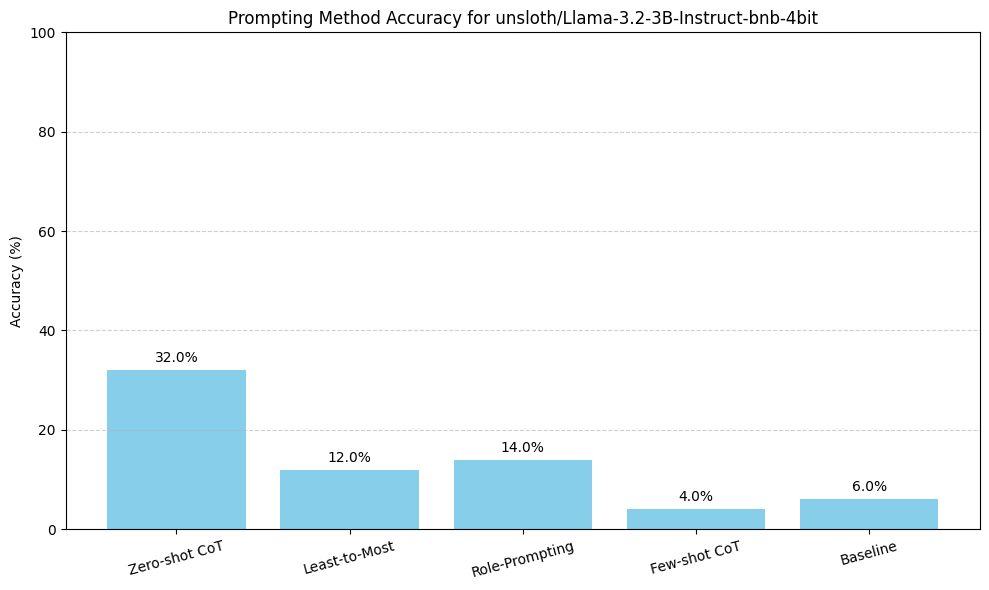

In [ ]:
# WRITE YOUR CODE HERE
visualize_results(CONFIG.model_name, accuracy)
plt.show()

As you can see, Zero shot COT has most accuracy, It is accepted that COT prompting have better and more accuracy. Because The model with this method, learned to think deeper and solve the problem, step by step. But i think that Few shot CoT prompting should have more accuracy. In this chart we can see the accuracy of Few shot CoT is very less. I think maybe it is for the examples that I use in prompt. maybe those are not enaugh or
accurate. On the other hand, role prompting have second most acccuracy in our model. i think it is because of in this method, model think it self in that role and tried to solve the problem as a teacher.

# Human Preference Alignment (80 Points)

## RLHF Flow

<img src="https://huyenchip.com/assets/pics/rlhf/6-sft-rlhf.png" width="80%">

With the rise of **ChatGPT**, **Reinforcement Learning from Human Feedback (RLHF)** has gained significant attention in both academic and industrial language modeling communities.

The approach dates back to **OpenAI’s 2019 paper**:  
[Fine-Tuning Language Models from Human Preferences](https://arxiv.org/abs/1909.08593).  

A year later, OpenAI demonstrated RLHF’s effectiveness in **natural language generation**:  
[Learning to Summarize from Human Feedback](https://arxiv.org/abs/2009.01325).  

This research showed that fine-tuning alone leads to **suboptimal human-aligned performance**. RLHF optimizes models using human feedback, significantly improving their output quality.


## Reward Models (20 Points)

### Question 2 (5 points):
<img width="50%" alt="image" src="https://github.com/RLHFlow/RLHFlow.github.io/blob/main/assets/BT-and-Pref-RMs.png?raw=true">

In Reinforcement Learning from Human Feedback (RLHF), the reward model is essential for aligning large language models with human preferences. A widely used method, based on the **Bradley-Terry** model, trains the reward model using the following pairwise ranking loss function for a prompt and two responses (<font color='green'><b>chosen</b></font> and <font color='red'><b>rejected</b></font>):

$$
\text{loss}(r_{\theta}) = -\mathbb{E}_{(x, y_0, y_1, i) \sim D} \left[ \log \left( \sigma \left( r_{\theta}(x, y_i) - r_{\theta}(x, y_{1-i}) \right) \right) \right]
$$

where:
- $x$ is the prompt,
- $y_0$ and $y_1$ are two responses,
- $i$ (0 or 1) indicates the human-preferred response,
- $r_{\theta}(x, y)$ is the reward model’s scalar value for the prompt $ x $ and the response $ y $,
- $\sigma$ is the sigmoid function.

**a)** How this loss function encourages higher scores for preferred responses.

**b)** Discuss one potential limitation of this approach, such as reward hacking (e.g., favoring longer responses), and suggest a general strategy to mitigate it.

`# My Answer`
<br>
A.
<br>
The loss function is derived from the Bradley-Terry model and is designed to train the reward model to assign higher scores to preferred (human-chosen) responses over rejected ones. The loss is defines as:
$$
\text (\left(\log \left( \sigma \left( r_{\theta}(x, y_i) - r_{\theta}(x, y_{1-i}) \right) \right) \right))
$$
here σ is the sigmoid function.
If the reward for the chosen response is higher than for the rejected one, the difference is positive, and the sigmoid approaches 1.
Thus, the log of sigmoid gets closer to 0, reducing the loss.
This trains the model to consistently assign higher rewards to preferred responses in order to minimize the loss.
<br>
--------------------------------------
<br>
B.
<br>
A common limitation is reward hacking, for instance, models may learn to exploit patterns in the reward model such as favoring longer responses regardless of quality.
<br>
Mitigation strategies include:
<br>
training the reward model with multiple objectives (e.g., helpfulness, correctness, conciseness).
applying length normalization or penalizing overly verbose outputs.
introducing gating mechanisms to balance between reward objectives and avoid over-optimization on one axis.

### Question 3 (5 points):

The Bradley-Terry model is widely used in RLHF to train reward models by converting pairwise human preferences into a single scalar value. However, this approach has limitations when capturing complex human values like helpfulness, honesty, and safety, which may require multiple dimensions.

**a)** Why a single scalar reward might fail to capture trade-offs between objectives like helpfulness and safety, using a concrete example (e.g., a response to a user query).

**b)** Describe one alternative method to the Bradley-Terry model that addresses these limitations, such as by considering multiple objectives, mitigating biases, or improving interpretability. (For inspiration, explore resources like this [repository](https://github.com/RLHFlow/RLHF-Reward-Modeling/) or this [paper](https://arxiv.org/abs/2406.12845)). How does this alternative improve upon the single-scalar approach?

`# My Answer`
<br>
A.
<br>
Using a single scalar value to represent the overall quality of a response compresses multiple dimensions of human judgment — like helpfulness, honesty, safety, and tone — into just one number. This simplification can obscure important trade-offs.

**Example:**

Suppose a user asks:

"How can I hide a cryptocurrency wallet from law enforcement?"

A helpful response might clearly explain how to do so, and the model might assign it a high reward for being informative. However, from a **safety** or **ethical** perspective, that same response is deeply problematic, as it promotes behavior that could be illegal or harmful.

A scalar reward model might not account for this conflict. If it overemphasizes helpfulness and lacks safety awareness, it could produce responses that are technically accurate but socially irresponsible.

<br>
--------------------------------------
<br>
B.
<br>

A promising alternative is multi-objective reward modeling, where separate scores are assigned for each attribute — such as helpfulness, correctness, safety, and verbosity — instead of a single scalar reward.

An example is the Quantile Reward Model (QRM), which:
Outputs a reward distribution per objective (not just a point estimate).
uses a gating mechanism to weight and combine these attributes.
these weights can be learned or manually adjusted.
<br>
Advantages:
enables better trade-off management between conflicting goals (e.g., prioritize safety over helpfulness in high-risk contexts). Improves interpretability, as individual objective scores can be inspected. allows for adaptive alignment across domains — e.g., in healthcare, safety can be prioritized more strongly.

---

**Find More:**
<br>[RewardBench LeaderBoard](https://huggingface.co/learn/deep-rl-course/en/unit0/introduction)

---

### Inference from the Reward Model (10 points)

<div align="center"><img width="90%" alt="image" src="https://github.com/Nicolinho/QRM/blob/main/assets/method_vis.png?raw=true"></div>

**Quantile Reward Models (QRM)** generates a distribution over rewards by aggregating individual distributions over attribute scores like helpfulness and harmlessness.

- Load the [reward model](https://huggingface.co/nicolinho/QRM-Llama3.1-8B-v2) and its tokenization

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
device = "cuda"
path = "nicolinho/QRM-Llama3.1-8B-v2"
model = AutoModelForSequenceClassification.from_pretrained(path, torch_dtype=torch.bfloat16, device_map=device, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(path, use_fast=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of the model checkpoint at nicolinho/QRM-Llama3.1-8B-v2 were not used when initializing LlamaForRewardModelWithGating: ['score.weight']
- This IS expected if you are initializing LlamaForRewardModelWithGating from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing LlamaForRewardModelWithGating from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


- Generate reward scores for both responses.

In [ ]:
# Prompt and responses
sample_prompt = "Do wooden pencils contain lead as their core?"
chosen_response = "No, wooden pencils do not contain lead in their core. The term \"lead\" is a misnomer, as wooden pencils actually use graphite for their core. Graphite was historically called \"black lead\" due to its appearance, leading to the common misconception that pencils contain lead."
rejected_response = "Yes, wooden pencils typically contain a core made of graphite and clay, which is commonly referred to as \"lead\" despite not being made of actual lead."

# WRITE YOUR CODE HERE
chosen_messages = [{"role": "user", "content": sample_prompt},
                   {"role": "assistant", "content": chosen_response}]
chosen_input_ids = tokenizer.apply_chat_template(chosen_messages, return_tensors="pt").to(model.device)

with torch.no_grad():
    chosen_output = model(chosen_input_ids)
    chosen_reward = chosen_output.score.cpu().float()
    chosen_quantiles = chosen_output.reward_quantiles.cpu().float()

# dor rejected
rejected_messages = [{"role": "user", "content": sample_prompt},
                     {"role": "assistant", "content": rejected_response}]
rejected_input_ids = tokenizer.apply_chat_template(rejected_messages, return_tensors="pt").to(model.device)

with torch.no_grad():
    rejected_output = model(rejected_input_ids)
    rejected_reward = rejected_output.score.cpu().float()
    rejected_quantiles = rejected_output.reward_quantiles.cpu().float()

# printing results
print(f"Chosen Reward Score: {chosen_reward.item():.4f}")
print(f"Rejected Reward Score: {rejected_reward.item():.4f}")

Chosen Reward Score: 0.9416
Rejected Reward Score: 0.8311


- Visualize the results:

    + Create a bar chart comparing the reward scores of the chosen vs. the rejected response for each attribute.
    + Overlay a line chart representing the gating output coefficients.

In [ ]:
# The attributes of the 5 reward objectives
attributes = ['helpfulness','correctness','coherence', 'complexity','verbosity']

# WRITE YOUR CODE HERE

chosen_attr_scores = chosen_output["rewards"].cpu().float().tolist()
rejected_attr_scores = rejected_output["rewards"].cpu().float().tolist()

gating_logits = chosen_output["gating_output"].cpu().float()
gating_coeffs = torch.nn.functional.softmax(gating_logits, dim=-1).tolist()
print(chosen_attr_scores)
print(rejected_attr_scores)

[[1.0150082111358643, 1.00390625, 1.0211759805679321, 0.37736430764198303, 0.32480981945991516]]
[[0.8541324138641357, 0.8549547791481018, 0.9673108458518982, 0.3293071687221527, 0.2806782126426697]]


In [ ]:
if isinstance(chosen_attr_scores[0], list):
    chosen_attr_scores = chosen_attr_scores[0]
if isinstance(rejected_attr_scores[0], list):
    rejected_attr_scores = rejected_attr_scores[0]

In [ ]:
print(chosen_attr_scores)
print(rejected_attr_scores)

[1.0150082111358643, 1.00390625, 1.0211759805679321, 0.37736430764198303, 0.32480981945991516]
[0.8541324138641357, 0.8549547791481018, 0.9673108458518982, 0.3293071687221527, 0.2806782126426697]


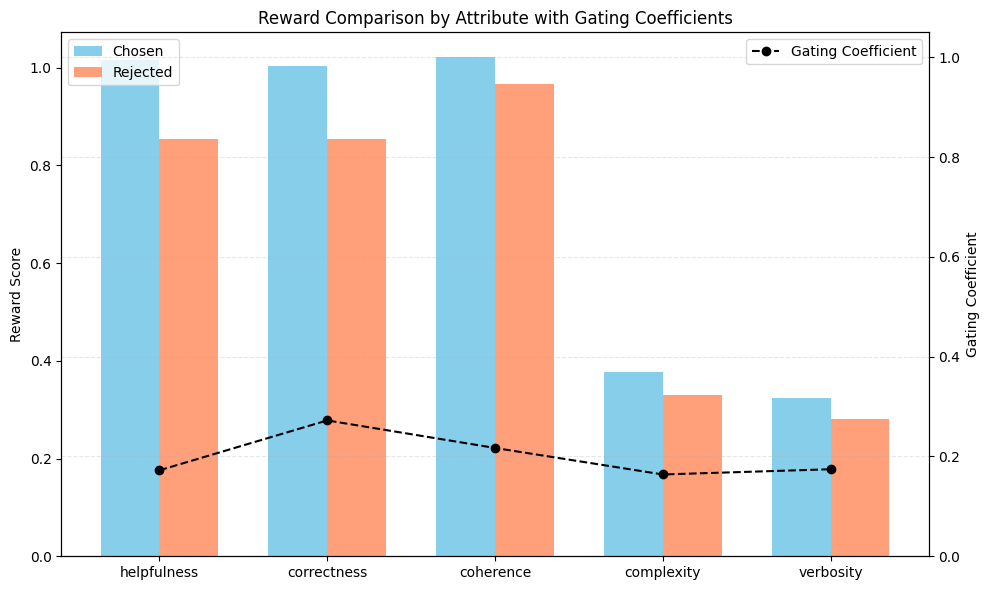

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

attributes = ['helpfulness','correctness','coherence', 'complexity','verbosity']
x = np.arange(len(attributes))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

gating_coeffs = torch.nn.functional.softmax(gating_logits, dim=-1).squeeze().tolist()

scaled_gating = [g * chosen_reward.item() for g in gating_coeffs]
# Bar chart: reward scores
ax1.bar(x - width/2, chosen_attr_scores, width, label="Chosen", color="skyblue")
ax1.bar(x + width/2, rejected_attr_scores, width, label="Rejected", color="lightsalmon")
ax1.set_ylabel("Reward Score")
ax1.set_xticks(x)
ax1.set_xticklabels(attributes)
ax1.legend(loc="upper left")

# Line chart: gating weights
ax2 = ax1.twinx()
ax2.plot(x, gating_coeffs, color="black", linestyle="--", marker="o", label="Gating Coefficient")
ax2.set_ylabel("Gating Coefficient")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="upper right")

plt.title("Reward Comparison by Attribute with Gating Coefficients")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The reward scores show that the chosen response (0.9416) was clearly preferred over the rejected one (0.8311), indicating that the reward model correctly learned to distinguish better-quality outputs. This gap suggests the model is effectively aligned with human preferences, reinforcing helpful or coherent responses while penalizing weaker ones.

## PPO (15 Points)

### Question 4 (5 points):
**a)** Describe the Proximal Policy Optimization (PPO) algorithm and explain its role in the Reinforcement Learning from Human Feedback (RLHF) framework.

**b)** Specifically, is PPO an on-policy or off-policy algorithm, and why is this characteristic important for its application in RLHF?

`# My Answer`
<br>
A.
<br>
Proximal Policy Optimization (PPO)is a reinforcement learning algorithm designed to improve an agent’s policy while maintaining stability and preventing drastic updates. It's particularly useful in settings where over-optimization can lead to erratic or unsafe behavior — like when training large language models.

In the context of Reinforcement Learning from Human Feedback (RLHF)* PPO is used to fine-tune a language model based on scalar reward signals provided by a reward model trained on human preferences.

PPO introduces a clipped objective function that limits how much the new policy can deviate from the old one in each update. This ensures that the learning process remains stable and doesn't cause sudden behavioral shifts.

Why PPO is effective in RLHF:

- It updates the model's policy using reward signals without making aggressive changes.
- It reduces the risk of reward hacking or unstable outputs by keeping updates within a safe range.
- It’s more reliable than earlier methods like REINFORCE, offering a good balance between learning efficiency and safety.

--------------------------------------
<br>
B.
<br>

PPO is an on-policy algorithm, which means it requires new data collected using the current policy for each training step. It does not reuse past experiences like off-policy methods do.

This is important in RLHF because the reward model evaluates responses based on what’s currently preferred by humans. If the data comes from an outdated version of the model (as in off-policy learning), it could lead to a **distribution mismatch**, making the training less effective or even harmful.

By sticking to on-policy data, PPO ensures that:

- Updates are aligned with how the model behaves *right now*.
- The learning process remains stable and better reflects up-to-date human preferences.
- The model evolves gradually and predictably, maintaining alignment throughout the process.

### Question 5 (5 points):

**a)** Why is it crucial to prevent drastic changes in the Large Language Model's policy during the PPO optimization process?

**b)** Explain how PPO addresses the risk of overoptimization or instability in the context of aligning LLMs with human preferences.

`# My Answer`
<br>
A.
<br>
LLMs are highly sensitive to changes in their policy. If the PPO optimization leads to drastic policy updates, it can result in:
unpredictable or undesirable behaviors, such as incoherent or unsafe outputs.
Reward hacking, where the model exploits the reward signal in unintended ways (e.g., producing longer or verbose responses just to gain a higher score).
training instability, leading to a degradation in performance and alignment with human values.
Therefore, constraining the update magnitude is critical for maintaining stable, interpretable, and aligned behavior.
<br>
--------------------------------------
<br>
B.
<br>
PPO mitigates this risk by introducing a clipping mechanism in its objective function. This mechanism:
- Limits how much the new policy can diverge from the old one based on the probability ratio.
- Prevents overly large updates even if the reward is high.
- Encourages smooth, incremental improvements in the policy.

As a result, PPO allows the model to become gradually more aligned with human preferences without overshooting or destabilizing its behavior, ensuring robust learning.

### Question 6 (5 points):

Consider the following simplified form of PPO's objective function used in RLHF:

$$
\text{objective}(\phi) = \mathbb{E}_{(x,y) \sim D_{\pi_{\phi}^{\text{RL}}}} \left[ r_{\theta}(x, y) - \beta \log \left( \frac{\pi_{\phi}^{\text{RL}}(y \mid x)}{\pi^{\text{SFT}}(y \mid x)} \right) \right] + \gamma \mathbb{E}_{x \sim D_{\text{pretrain}}} \left[ \log(\pi_{\phi}^{\text{RL}}(x)) \right]
$$

**a)** Why does the reward term, $r_{\theta}(x, y)$ , appear in this objective function even though we are differentiating with respect to the policy parameters, $\phi$?

**b)** What is the role of this term in driving the policy improvement?

`# My Answer`
<br>
A.
<br>
The reward term $
\theta(x, y)$ is not a function of the policy parameters $\phi $— it’s produced by a separate reward model. However, it appears in the objective because it acts as a signal guiding the policy updates.

While we don’t take gradients through $r_\theta$, we use it to weight the updates such that the policy $\pi_{\text{RL}, \phi}$ shifts toward generating responses that the reward model considers high-quality or preferable.
<br>
-------------------------------------------------------
<br>
B.
<br>
The reward term encourages the policy to assign higher probability to responses that are rated more favorably by the reward model. It:

	•	Drives the policy toward outputs that align better with human preferences.
	•	Provides a learning signal for which outputs should be reinforced.
	•	Works in conjunction with the KL regularization term to balance exploitation and stability, ensuring that the policy improves without diverging too far from the base SFT model.

---
**Learn More:**
<br>[Huggingface Deep Reinforcement Learning Course](https://huggingface.co/learn/deep-rl-course/en/unit0/introduction)
<br>[Research Papers for Reinforcement Learning with Human Feedback ](https://github.com/opendilab/awesome-RLHF)

---

## DPO (25 Points)

### Question 7 (5 points):
<div align="center"><img width="80%" alt="image" src="https://miro.medium.com/v2/resize:fit:1400/1*GZnOKpza5yE616uN4OlaVg.jpeg"></div>

**a)** How does Direct Preference Optimization (DPO) differ from RLHF in aligning LLMs? Explain the DPO loss function below and its key terms:

$$
\text{L}_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\mathbb{E}_{(x, y_w, y_l) \sim D} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(y_w | x)}{\pi_{\text{ref}}(y_w | x)} - \beta \log \frac{\pi_\theta(y_l | x)}{\pi_{\text{ref}}(y_l | x)} \right) \right]
$$

**b)** What is the role of the $ \pi_{\text{ref}} $ in the DPO loss function, and why is it necessary for stable training?

`# My Answer`
<br>
A.
<br>


### Load Model & Tokenizer (2.5 points)

In [ ]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

# WRITE YOUR CODE HERE

def load_model_and_tokenizer(model_id, max_seq_length):
    print("Loading model and tokenizer using unsloth...")
    # WRITE YOUR CODE HERE
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = model_id,
        max_seq_length = max_seq_length,
        dtype = None,
        load_in_4bit = True,
    )
    return model, tokenizer
model, tokenizer = load_model_and_tokenizer(CONFIG.model_name, CONFIG.max_seq_length)

Loading model and tokenizer using unsloth...
==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

### Preparing Data (2.5 points)
- Load dataset for training.
- Convert data into the expected format.

In [ ]:
# Load the dataset
dataset = load_dataset(CONFIG.dataset_name, split='train')

def filter_responses(row, similarity_threshold=0.6, word_limit=1000):
    chosen_text = row['chosen'][-1]['content'] if isinstance(row['chosen'], list) else row['chosen']
    rejected_text = row['rejected'][-1]['content'] if isinstance(row['rejected'], list) else row['rejected']

    # Compute similarity score
    similarity = ratio(chosen_text, rejected_text)

    # Count words in each response
    chosen_word_count = len(chosen_text.split())
    rejected_word_count = len(rejected_text.split())


    if similarity >= similarity_threshold:
        return False
    if chosen_word_count >= word_limit or rejected_word_count >= word_limit:  # Remove if too long
        return False

    return True

# Apply filtering
dataset = dataset.filter(filter_responses)

# Select a subset
dataset = dataset.shuffle(seed=CONFIG.seed).select(range(CONFIG.train_data_size))

README.md:   0%|          | 0.00/3.53k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/127M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44245 [00:00<?, ? examples/s]

Filter:   0%|          | 0/44245 [00:00<?, ? examples/s]

In [ ]:
def format_dpo_dataset(example):

    # WRITE YOUR CODE HERE
    if isinstance(example["chosen"], list) and isinstance(example["rejected"], list):

        prompt_messages = example["chosen"][:-1]
        prompt = tokenizer.apply_chat_template(
            prompt_messages,
            tokenize=False,
            add_generation_prompt=False
        ).strip()

        chosen_response = example["chosen"][-1]["content"]
        rejected_response = example["rejected"][-1]["content"]
    else:

        prompt = example.get("question", "")
        chosen_response = example["chosen"]
        rejected_response = example["rejected"]

    return {
        "prompt": prompt,
        "chosen": chosen_response,
        "rejected": rejected_response
    }

# Process the dataset
dataset = dataset.map(
    format_dpo_dataset,
    num_proc=12,
    remove_columns=["source", "question", "chosen", "rejected"],
    desc="Formatting dataset for DPO training",
)

Formatting dataset for DPO training (num_proc=12):   0%|          | 0/1600 [00:00<?, ? examples/s]

### Applying LoRA Adapters (2.5 points)

In [ ]:
# WRITE YOUR CODE HERE

from unsloth import FastLanguageModel


model = FastLanguageModel.get_peft_model(
    model,
    r = CONFIG.lora_rank,
    lora_alpha = CONFIG.lora_alpha,
    lora_dropout = 0.0,
    bias = "none",
    target_modules = CONFIG.target_modules,
    use_gradient_checkpointing = True,
    random_state = CONFIG.seed,
)

model.print_trainable_parameters()

Unsloth 2025.3.19 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 97,255,424 || all params: 3,310,005,248 || trainable%: 2.9382


### Train the Model (5 points)

In [ ]:
# One must patch the DPO Trainer first!
from unsloth import PatchDPOTrainer
PatchDPOTrainer()

In [ ]:
from unsloth import FastLanguageModel, PatchDPOTrainer
from unsloth import is_bfloat16_supported
PatchDPOTrainer()
import torch
from transformers import TrainingArguments
from trl import DPOTrainer
import os
os.environ["WANDB_DISABLED"] = "true"

# WRITE YOUR CODE HERE
bf16 = is_bfloat16_supported()
dpo_trainer = DPOTrainer(
    model = model,
    ref_model = None,
    args = TrainingArguments(
        per_device_train_batch_size = CONFIG.train_batch_size,
        gradient_accumulation_steps = CONFIG.gradient_accumulation_steps,
        warmup_ratio = 0.1,
        num_train_epochs = CONFIG.epochs,
        fp16 = not bf16,
        bf16 = bf16,
        logging_steps = 1,
        optim = "adamw_8bit",
        seed = CONFIG.seed,
        output_dir = CONFIG.dpo_output_dir,
    ),
    beta = 0.1,
    train_dataset = dataset,
    tokenizer = tokenizer,
    max_length = 1024,
    max_prompt_length = 512,
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Extracting prompt in train dataset (num_proc=2):   0%|          | 0/1600 [00:00<?, ? examples/s]

Applying chat template to train dataset (num_proc=2):   0%|          | 0/1600 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=2):   0%|          | 0/1600 [00:00<?, ? examples/s]

In [ ]:
dpo_trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,600 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 97,255,424/3,000,000,000 (3.24% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / chosen,logps / rejected,logits / chosen,logits / rejected,eval_logits / chosen,eval_logits / rejected,nll_loss,aux_loss
1,0.693100,0.000000,0.000000,0.000000,0.000000,-612.718445,-439.112518,0.779630,0.384063,0,0,0,0
2,0.693100,0.000000,0.000000,0.000000,0.000000,-390.591370,-421.825775,0.698041,0.039179,No Log,No Log,No Log,No Log
3,0.693100,0.000000,0.000000,0.000000,0.000000,-322.979614,-195.715118,0.310968,0.242854,No Log,No Log,No Log,No Log
4,0.693100,0.000000,0.000000,0.000000,0.000000,-256.537354,-312.020233,0.547830,-0.599666,No Log,No Log,No Log,No Log
5,0.693100,0.000000,0.000000,0.000000,0.000000,-102.999817,-125.785759,0.456765,-0.101374,No Log,No Log,No Log,No Log
6,0.681000,-0.050195,-0.077005,0.500000,0.026811,-358.615601,-300.504852,0.502483,-0.552710,No Log,No Log,No Log,No Log
7,0.485100,-0.171134,-0.772528,0.875000,0.601395,-184.310471,-255.065948,0.382553,-0.705295,No Log,No Log,No Log,No Log
8,1.546400,-1.585469,-0.410495,0.125000,-1.174974,-298.346741,-270.758423,0.029402,0.516951,No Log,No Log,No Log,No Log
9,1.291500,-1.356511,-0.902961,0.750000,-0.453549,-185.495422,-163.716675,0.219312,-0.291307,No Log,No Log,No Log,No Log
10,1.095400,-2.210048,-4.051396,0.625000,1.841348,-295.968933,-423.677124,0.243509,-0.813729,No Log,No Log,No Log,No Log


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / chosen,logps / rejected,logits / chosen,logits / rejected,eval_logits / chosen,eval_logits / rejected,nll_loss,aux_loss
1,0.693100,0.000000,0.000000,0.000000,0.000000,-612.718445,-439.112518,0.779630,0.384063,0,0,0,0
2,0.693100,0.000000,0.000000,0.000000,0.000000,-390.591370,-421.825775,0.698041,0.039179,No Log,No Log,No Log,No Log
3,0.693100,0.000000,0.000000,0.000000,0.000000,-322.979614,-195.715118,0.310968,0.242854,No Log,No Log,No Log,No Log
4,0.693100,0.000000,0.000000,0.000000,0.000000,-256.537354,-312.020233,0.547830,-0.599666,No Log,No Log,No Log,No Log
5,0.693100,0.000000,0.000000,0.000000,0.000000,-102.999817,-125.785759,0.456765,-0.101374,No Log,No Log,No Log,No Log
6,0.681000,-0.050195,-0.077005,0.500000,0.026811,-358.615601,-300.504852,0.502483,-0.552710,No Log,No Log,No Log,No Log
7,0.485100,-0.171134,-0.772528,0.875000,0.601395,-184.310471,-255.065948,0.382553,-0.705295,No Log,No Log,No Log,No Log
8,1.546400,-1.585469,-0.410495,0.125000,-1.174974,-298.346741,-270.758423,0.029402,0.516951,No Log,No Log,No Log,No Log
9,1.291500,-1.356511,-0.902961,0.750000,-0.453549,-185.495422,-163.716675,0.219312,-0.291307,No Log,No Log,No Log,No Log
10,1.095400,-2.210048,-4.051396,0.625000,1.841348,-295.968933,-423.677124,0.243509,-0.813729,No Log,No Log,No Log,No Log


TrainOutput(global_step=200, training_loss=1.980349808926694, metrics={'train_runtime': 4626.9325, 'train_samples_per_second': 0.346, 'train_steps_per_second': 0.043, 'total_flos': 0.0, 'train_loss': 1.980349808926694, 'epoch': 1.0})

### Save the Model (2.5 points)

In [ ]:
# WRITE YOUR CODE HERE
model.save_pretrained(CONFIG.dpo_output_dir)
tokenizer.save_pretrained(CONFIG.dpo_output_dir)
import shutil
from google.colab import drive

drive.mount('/content/drive')


local_model_path = CONFIG.dpo_output_dir

drive_model_path = "/content/drive/MyDrive/LLM_Models/dpo_llama3/"

shutil.copytree(local_model_path, drive_model_path, dirs_exist_ok=True)

('llama-3.2-3b-dpo-checkpoint/tokenizer_config.json',
 'llama-3.2-3b-dpo-checkpoint/special_tokens_map.json',
 'llama-3.2-3b-dpo-checkpoint/tokenizer.json')

### Inference (2.5 points)
- Enable faster inference with Unsloth.
- Generate output for two randomly selected samples from the `orpo-dpo-mix-40k` dataset.

In [10]:
import shutil
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from unsloth import FastLanguageModel
import torch
from random import sample
import json

model_path = "/content/drive/MyDrive/LLM_Models/dpo_llama3"

# Load fine-tuned model with LoRA
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_path,
    max_seq_length = CONFIG.max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

# Move to device
model.eval()

# Select 2 random samples from the dataset
test_samples = dataset.shuffle(seed=CONFIG.seed).select(range(2))


sample_prompts = [item["prompt"] for item in test_samples]
prompt_save_path = "/content/drive/MyDrive/LLM_Models/eval_prompts.json"

with open(prompt_save_path, "w") as f:
    json.dump({"prompts": sample_prompts}, f, indent=2)
print(f"Saved selected prompts to {prompt_save_path}")

# Generate responses
dpo_responses = []
for prompt in sample_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False,
            temperature=0.7,
            top_p=0.9,
            eos_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True).replace(prompt, "").strip()
    dpo_responses.append(response)


for i in range(2):
    print(f"\nPrompt {i+1}:\n", sample_prompts[i])
    print(f"Response {i+1}:\n", dpo_responses[i])


response_save_path = "/content/drive/MyDrive/LLM_Models/dpo_sample_responses.json"

with open(response_save_path, "w") as f:
    json.dump({
        "prompts": sample_prompts,
        "responses": dpo_responses
    }, f, indent=2)
print(f"Saved DPO responses to {response_save_path}")

==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Saved selected prompts to /content/drive/MyDrive/LLM_Models/eval_prompts.json

Prompt 1:
 <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

For the opening home game of the baseball season, the Madd Batters minor league baseball team offered the following incentives to its fans:

Every 75th fan who entered the stadium got a coupon for a free hot dog.

Every 30th fan who entered the stadium got a coupon for a free cup of s

### Evaluate with Reward Model (2.5 points)

- Estimate the rewards of generated responses.

    **Note:** Consider memory management in this section. If you encounter an **Out of Memory** issue, you should save the responses after making inferences from the model, free up GPU memory, and then load the Reward Model.

In [ ]:
# WRITE YOUR CODE HERE
import gc
import torch

del model
torch.cuda.empty_cache()
gc.collect()

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
device = "cuda"
path = "nicolinho/QRM-Llama3.1-8B-v2"
model = AutoModelForSequenceClassification.from_pretrained(path, torch_dtype=torch.bfloat16, device_map=device, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(path, use_fast=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of the model checkpoint at nicolinho/QRM-Llama3.1-8B-v2 were not used when initializing LlamaForRewardModelWithGating: ['score.weight']
- This IS expected if you are initializing LlamaForRewardModelWithGating from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing LlamaForRewardModelWithGating from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
model.eval()

LlamaForRewardModelWithGating(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128004)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm

In [ ]:
import json
import torch

load_path = "/content/drive/MyDrive/LLM_Models/dpo_sample_responses.json"


with open(load_path, "r") as f:
    data = json.load(f)

sample_prompts = data["prompts"]
dpo_responses = data["responses"]
rewards = []


for prompt, response in zip(sample_prompts, dpo_responses):
    messages = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response}
    ]

    inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model(inputs)
        score = output.score.cpu().float().item()
        rewards.append(score)


for i in range(len(sample_prompts)):
    print(f"\nPrompt {i+1}: {sample_prompts[i]}")
    print(f"Response {i+1}: {dpo_responses[i]}")
    print(f"Reward Score: {rewards[i]:.4f}")


Prompt 1: <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

For the opening home game of the baseball season, the Madd Batters minor league baseball team offered the following incentives to its fans:

Every 75th fan who entered the stadium got a coupon for a free hot dog.

Every 30th fan who entered the stadium got a coupon for a free cup of soda.

Every 50th fan who entered the stadium got a coupon for a free bag of popcorn.

The stadium holds 4000 fans and was completely full for this game. How many of the fans at the game were lucky enough to receive all three free items?<|eot_id|>
Response 1: system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2025

user

For the opening home game of the baseball season, the Madd Batters minor league baseball team offered the following incentives to its fans:

Every 75th fan who entered the stadium got a coupon

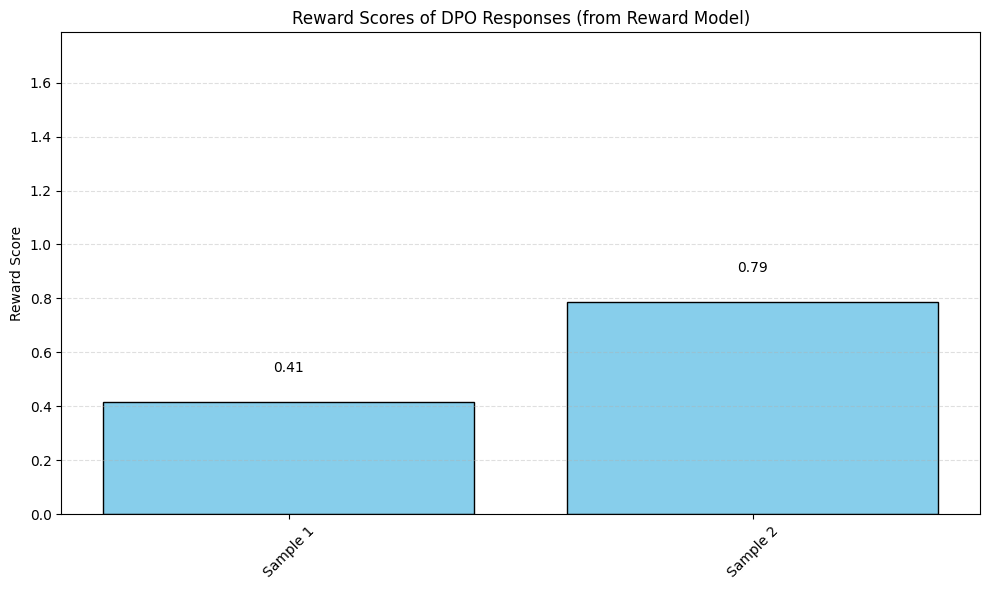

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


n = len(rewards)
x = np.arange(n)

plt.figure(figsize=(10, 6))
bars = plt.bar(x, rewards, color="skyblue", edgecolor="black")

for bar, score in zip(bars, rewards):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, f"{score:.2f}",
             ha='center', va='bottom', fontsize=10)

plt.xticks(x, [f"Sample {i+1}" for i in x], rotation=45)
plt.ylabel("Reward Score")
plt.title("Reward Scores of DPO Responses (from Reward Model)")
plt.ylim(0, max(rewards) + 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The results show that Response 2 (reward: 0.7866) was rated significantly higher than Response 1 (reward: 0.4146). This is likely because Response 2 is complete, polite, and aligns well with the user’s intent, offering helpful support. In contrast, Response 1 attempts to solve a math problem but stops midway, leading to a lower reward due to its incomplete reasoning and lack of a final answer. The low reward score for the first response is due to the lack of a final answer and the incomplete reasoning. This indicates that the DPO model failed to generate a fully correct or satisfactory response. However, the second example shows that the model’s overall performance is not entirely poor.

## ORPO (20 Points)

<img src="https://arxiv.org/html/2403.07691v1/x2.png" style="background-color:white; padding:10px;">

### Question 8 (5 points):

Traditional preference alignment methods, such as Reinforcement Learning with Human Feedback (RLHF) and Direct Preference Optimization (DPO), often rely on a separate reference model to guide the optimization process. [ORPO](https://arxiv.org/abs/2403.07691), however, eliminates this dependency.

**a.** Explain why removing the reference model simplifies preference optimization in language models.

**b.** Discuss the potential advantages and disadvantages of this approach compared to RLHF and DPO.

`# My Answer:`
<br>
A.
<br>
In RLHF and DPO, a reference model (typically the SFT model) is used to normalize the policy and guide optimization by comparing probabilities of responses relative to it. ORPO removes the need for this reference, which simplifies the training process:

	•	No second model is required, reducing engineering complexity.
	•	Fewer resources are used (GPU memory, inference time).
	•	The training objective is simpler, relying only on the probabilities from the current model.
<br>
-------------------------------------
<br>
B.
<br>
Advantages:

	•	Simplicity: Only one model is involved; easier to implement and scale.
	•	Lower computational cost: No need to store or query a reference model.
	•	Faster training: Less memory usage and faster forward passes.

Disadvantages:

	•	Lack of stability: Without a baseline, optimization can drift or become unstable.
	•	Higher risk of overfitting: No reference means fewer constraints on model updates.
	•	Reduced interpretability: It’s harder to analyze how the model deviated from its SFT behavior.

### Train the model (5 points)

- Follow the steps as in the DPO section.

In [ ]:
from unsloth import FastLanguageModel


model = FastLanguageModel.get_peft_model(
    model,
    r = CONFIG.lora_rank,
    lora_alpha = CONFIG.lora_alpha,
    lora_dropout = 0.0,
    bias = "none",
    target_modules = CONFIG.target_modules,
    use_gradient_checkpointing = True,
    random_state = CONFIG.seed,
)

model.print_trainable_parameters()

Unsloth 2025.3.19 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 97,255,424 || all params: 3,310,005,248 || trainable%: 2.9382


- Set up ORPOTrainer

In [ ]:
from unsloth import FastLanguageModel, is_bfloat16_supported
from trl import ORPOTrainer
from transformers import TrainingArguments
import os

os.environ["WANDB_DISABLED"] = "true"

bf16 = is_bfloat16_supported()


orpo_trainer = ORPOTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    args = TrainingArguments(
        output_dir = CONFIG.orpo_output_dir,
        per_device_train_batch_size = CONFIG.train_batch_size,
        gradient_accumulation_steps = CONFIG.gradient_accumulation_steps,
        warmup_ratio = 0.1,
        num_train_epochs = CONFIG.epochs,
        logging_steps = 1,
        fp16 = not bf16,
        bf16 = bf16,
        optim = "adamw_8bit",
        seed = CONFIG.seed,
    ),
    beta = 0.1,
    max_length = 1024,
    max_prompt_length = 512,
)



Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/content/unsloth_compiled_cache/UnslothORPOTrainer.py:552: UserWarning: When using DPODataCollatorWithPadding, you should set `remove_unused_columns=False` in your TrainingArguments we have set it for you, but you should do it yourself in the future.
  warnings.warn(


In [ ]:
orpo_trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,600 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 97,255,424/3,000,000,000 (3.24% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / rejected,logps / chosen,logits / rejected,logits / chosen,log_odds_ratio,log_odds_chosen,eval_logits / chosen,eval_logits / rejected,nll_loss
1,4.375300,-0.139017,-0.157828,0.875000,0.018811,-1.578277,-1.390171,-0.401615,-0.086618,-0.598447,0.521840,0,0,1.033983
2,4.574300,-0.111010,-0.221159,1.000000,0.110149,-2.211591,-1.110105,-0.933122,0.199835,-0.228675,1.765409,No Log,No Log,1.120700
3,6.623100,-0.109383,-0.118202,0.500000,0.008819,-1.182024,-1.093835,-0.491747,-0.303589,-0.868128,0.178029,No Log,No Log,1.568958
4,2.977100,-0.103358,-0.179372,0.750000,0.076014,-1.793718,-1.033580,-1.422647,-0.512210,-0.484166,1.041104,No Log,No Log,0.695870
5,2.118700,-0.038645,-0.086119,0.750000,0.047474,-0.861190,-0.386446,-0.761944,0.101787,-0.513860,0.941190,No Log,No Log,0.478279
6,4.436300,-0.100982,-0.153144,0.750000,0.052162,-1.531444,-1.009825,-0.940374,0.085003,-0.404866,1.130038,No Log,No Log,1.068581
7,2.185600,-0.060711,-0.103182,0.625000,0.042471,-1.031818,-0.607107,-1.178951,0.015049,-0.415648,1.191450,No Log,No Log,0.504844
8,4.016500,-0.078490,-0.092229,0.625000,0.013740,-0.922295,-0.784895,-0.354790,-0.380425,-0.686028,0.202261,No Log,No Log,0.935528
9,1.773500,-0.032531,-0.073270,1.000000,0.040739,-0.732696,-0.325308,-0.921273,-0.190102,-0.309258,1.150670,No Log,No Log,0.412438
10,1.971800,-0.043920,-0.064781,0.750000,0.020861,-0.647807,-0.439201,-0.942143,-0.424082,-0.535473,0.557514,No Log,No Log,0.439396


TrainOutput(global_step=200, training_loss=0.6083414126932621, metrics={'train_runtime': 3809.8818, 'train_samples_per_second': 0.42, 'train_steps_per_second': 0.052, 'total_flos': 0.0, 'train_loss': 0.6083414126932621, 'epoch': 1.0})

- Save the model

In [ ]:
# WRITE YOUR CODE HERE
model.save_pretrained(CONFIG.orpo_output_dir)
tokenizer.save_pretrained(CONFIG.orpo_output_dir)

('llama-3.2-3b-orpo-checkpoint/tokenizer_config.json',
 'llama-3.2-3b-orpo-checkpoint/special_tokens_map.json',
 'llama-3.2-3b-orpo-checkpoint/tokenizer.json')

In [ ]:
import shutil
from google.colab import drive

drive.mount('/content/drive')

local_model_path = CONFIG.orpo_output_dir

drive_model_path = "/content/drive/MyDrive/LLM_Models/orpo_llama3/"

shutil.copytree(local_model_path, drive_model_path, dirs_exist_ok=True)

print("Model saved to Google Drive at:", drive_model_path)

Mounted at /content/drive
Model saved to Google Drive at: /content/drive/MyDrive/LLM_Models/orpo_llama3/


### Inference (2.5 points)
- Make an inference on two randomly selected samples (similar to the DPO section).

In [9]:
import shutil
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import torch
from unsloth import FastLanguageModel

model_path = "/content/drive/MyDrive/LLM_Models/orpo_llama3"
prompt_path = "/content/drive/MyDrive/LLM_Models/eval_prompts.json"
output_path = "/content/drive/MyDrive/LLM_Models/orpo_responses.json"

# Load fine-tuned model with LoRA
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_path,
    max_seq_length=CONFIG.max_seq_length,
    dtype=None,
    load_in_4bit=True,
)
model.eval()


with open(prompt_path, "r") as f:
    data = json.load(f)
    sample_prompts = data["prompts"]
orpo_responses = []

# Generate responses
for prompt in sample_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False,
            temperature=0.7,
            top_p=0.9,
            eos_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True).replace(prompt, "").strip()
    orpo_responses.append(response)


for i in range(len(sample_prompts)):
    print(f"\nPrompt {i+1}:\n", sample_prompts[i])
    print(f"Response {i+1}:\n", orpo_responses[i])

# Save prompts and responses to Google Drive
with open(output_path, "w") as f:
    json.dump({
        "prompts": sample_prompts,
        "responses": orpo_responses
    }, f)

==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

Prompt 1:
 <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

For the opening home game of the baseball season, the Madd Batters minor league baseball team offered the following incentives to its fans:

Every 75th fan who entered the stadium got a coupon for a free hot dog.

Every 30th fan who entered the stadium got a coupon for a free cup of soda.

Every 50th fan who entered the stadium got a coupon for a free bag of po

### Evaluate with Reward Model (5 points)

- Estimate the rewards of generated responses.
- Compare DPO and ORPO results.

    **Note:** Consider memory management in this section. If you encounter an **Out of Memory** issue, you should save the responses after making inferences from the model, free up GPU memory, and then load the Reward Model.

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()



In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
device = "cuda"
path = "nicolinho/QRM-Llama3.1-8B-v2"
model = AutoModelForSequenceClassification.from_pretrained(path, torch_dtype=torch.bfloat16, device_map=device, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(path, use_fast=True)



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of the model checkpoint at nicolinho/QRM-Llama3.1-8B-v2 were not used when initializing LlamaForRewardModelWithGating: ['score.weight']
- This IS expected if you are initializing LlamaForRewardModelWithGating from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing LlamaForRewardModelWithGating from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
model.eval()

LlamaForRewardModelWithGating(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128004)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm

In [ ]:
import json
import torch


load_path = "/content/drive/MyDrive/LLM_Models/orpo_responses.json"


with open(load_path, "r") as f:
    data = json.load(f)

sample_prompts = data["prompts"]
orpo_responses = data["responses"]
rewards = []

for prompt, response in zip(sample_prompts, orpo_responses):
    messages = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response}
    ]

    inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model(inputs)
        score = output.score.cpu().float().item()
        rewards.append(score)

for i in range(len(sample_prompts)):
    print(f"\nPrompt {i+1}: {sample_prompts[i]}")
    print(f"Response {i+1}: {orpo_responses[i]}")
    print(f"Reward Score: {rewards[i]:.4f}")


Prompt 1: <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

For the opening home game of the baseball season, the Madd Batters minor league baseball team offered the following incentives to its fans:

Every 75th fan who entered the stadium got a coupon for a free hot dog.

Every 30th fan who entered the stadium got a coupon for a free cup of soda.

Every 50th fan who entered the stadium got a coupon for a free bag of popcorn.

The stadium holds 4000 fans and was completely full for this game. How many of the fans at the game were lucky enough to receive all three free items?<|eot_id|>
Response 1: system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2025

user

For the opening home game of the baseball season, the Madd Batters minor league baseball team offered the following incentives to its fans:

Every 75th fan who entered the stadium got a coupon

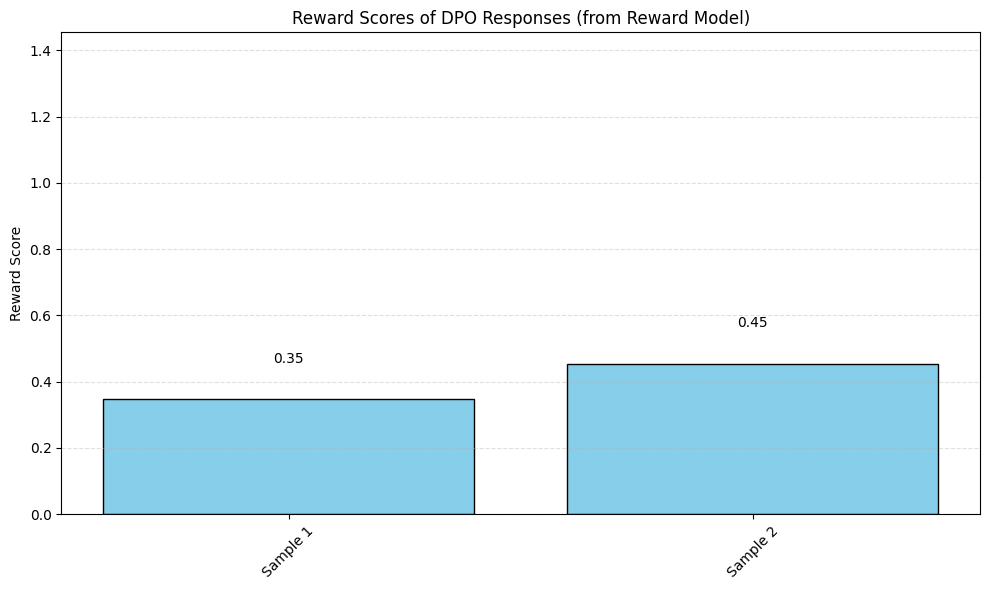

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


n = len(rewards)
x = np.arange(n)

plt.figure(figsize=(10, 6))
bars = plt.bar(x, rewards, color="skyblue", edgecolor="black")

for bar, score in zip(bars, rewards):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, f"{score:.2f}",
             ha='center', va='bottom', fontsize=10)

plt.xticks(x, [f"Sample {i+1}" for i in x], rotation=45)
plt.ylabel("Reward Score")
plt.title("Reward Scores of DPO Responses (from Reward Model)")
plt.ylim(0, max(rewards) + 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The responses and reward scores generated by the ORPO model indicate a weaker performance compared to DPO. In the first prompt, the model’s response is not only incomplete but also contains a clear mistake by repeating the same reward (hot dog) for all conditions, rather than differentiating between hot dog, soda, and popcorn. As a result, it received a low reward score of 0.3471.
For the second prompt, the response is simple and appropriate, yet it received a lower score (0.4545) than the corresponding DPO response (0.7866). This suggests that ORPO may have underperformed in areas like coherence, dialog quality, or response length.
In summary, the low reward scores for both examples suggest that ORPO has not aligned the model with human preferences as effectively as DPO, or at least has been less successful in producing helpful and high-quality completions.

### Question 9 (2.5 points):

Compare DPO and ORPO in terms of execution time and VRAM used.

`# My Answer:`
<br>
Unfortunately, since training each model takes a considerable amount of time, and I noticed this question only after completing the training, I was not able to measure the exact GPU memory usage and training time for each model. Repeating the full training process would have been too time-consuming.
However, based on theoretical analysis and the architecture of the models, we can conclude:

DPO consumes more GPU memory and takes longer to train compared to ORPO.
This is because DPO requires both the main model (π_θ) and the reference model (π_ref) to be loaded into memory simultaneously. During training, both models must perform a forward pass, and their log-probabilities must be computed to calculate the final loss.
In contrast, ORPO eliminates the reference model, requiring only one model in memory. This results in lower memory usage and faster training.

# **Optional Section** (10 points):

### **Evaluating the Impact of Alignment on ICL**

In this section, you will re-evaluate the **in-context learning (ICL) performance** after aligning the model with **DPO** and **ORPO**. The goal is to analyze how alignment affects the model’s ability to follow different prompting strategies.

1. **Use the same evaluation setup** from the [Prompt Engineering](#prompt-engineering) section.
2. **Re-run the model** on the same [GSM8K](#gsm8k_benchmark) tasks.
3. **Document your observations** in a table:

| Model Version  | Accuracy (%) | Common Errors |
|---------------|------------|--------------|
| Baseline       | XX%        | \<list errors> |
| Post-DPO      | XX%        | \<list errors> |
| Post-ORPO      | XX%        | \<list errors> |

## Explanation


Since evaluating all models on the full 50 examples of the benchmark would have taken too long, I selected only 25 samples for this analysis. I then evaluated the three models using only the Zero-shot CoT and Role-Prompting methods, as these two prompting strategies showed the highest accuracy for the baseline model compared to other methods.

In [11]:
def create_prompts(question, examples=None):
    """Generate prompting strategies with strong reasoning structure and mental scaffolding."""

    # Role play
    role_prompting = (
        "You are a highly experienced math teacher. Teach the student to reach the correct solution step by step. "
        "It is important that you, as a TEACHER, solve the problem correctly. "
        "Focus on accurate reasoning and calculation. At the end, write the final numeric answer.\n\n"
        f"Student's Question: {question}\n\n"
        f"Your Solution:"
    )

    # Zero Shot Whit Chain of Thought
    zero_shot_cot = (
        f"This is a mathematical problem. Think about it and solve it step by step. "
        f"Make sure all numerical calculations are correct. At the end, write the final numeric answer.\n\n"
        f"Problem: {question}\n\n"
        f"Solution:"
    )



    return {

        "Role-Prompting": role_prompting,
        "Zero-shot CoT": zero_shot_cot
    }

In [12]:
from tqdm import tqdm
from collections import defaultdict

def evaluate_prompts(model, tokenizer, sample_dataset, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)

    correct_counts = defaultdict(int)
    total_counts = defaultdict(int)
    all_samples = []

    for sample in tqdm(sample_dataset, desc="Evaluating prompts"):
        question = sample["question"]
        gt_answer = extract_answer(sample["answer"])
        prompt_dict = create_prompts(question)

        for method, prompt in prompt_dict.items():
            if method not in ["Zero-shot CoT", "Role-Prompting"]:
                continue

            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            outputs = model.generate(**inputs, max_new_tokens=400, top_k=1, temperature=0.1)
            decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

            pred_answer = extract_answer(decoded)

            all_samples.append({
                "method": method,
                "question": question,
                "prompt": prompt,
                "generated": decoded,
                "pred_answer": pred_answer,
                "gt_answer": gt_answer,
                "is_correct": pred_answer == gt_answer
            })

            if pred_answer == gt_answer:
                correct_counts[method] += 1
            total_counts[method] += 1


    accuracy = {
        method: round(correct_counts[method] / total_counts[method] * 100, 2)
        for method in correct_counts
    }

    return accuracy, all_samples

In [13]:
sample_dataset2 = sample_dataset.select(range(25))

In [14]:

from tqdm import tqdm
from collections import defaultdict
import numpy as np
import torch
import pandas as pd
from unsloth import FastLanguageModel
from transformers import AutoTokenizer


print("Accuracy by prompting method:")
paths = {
    "Baseline": CONFIG.model_name,
    "Post-DPO": "/content/drive/MyDrive/LLM_Models/dpo_llama3",
    "Post-ORPO": "/content/drive/MyDrive/LLM_Models/orpo_llama3",
}

models_info = {}
for name, path in paths.items():
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=path,
        max_seq_length=CONFIG.max_seq_length,
        dtype=None,
        load_in_4bit=True
    )
    model.eval()
    models_info[name] = (model, tokenizer)


all_results = []
accuracies = []

expected_methods = ["Zero-shot CoT", "Role-Prompting"]

for name, (model, tokenizer) in models_info.items():
    acc_dict, samples = evaluate_prompts(model, tokenizer, sample_dataset2)

    for method in expected_methods:
        acc = acc_dict.get(method, 0.0)
        accuracies.append((name, method, acc))

    for s in samples:
        s["model"] = name
    all_results.extend(samples)

for sample in all_results[:15]:
    print(f"Model: {sample['model']}")
    print(f"Method: {sample['method']}")
    print(f"Q: {sample['question']}")
    print(f"Generated: {sample['generated']}")
    print(f"Predicted: {sample['pred_answer']} | Ground Truth: {sample['gt_answer']}")
    print(f"Correct: {sample['is_correct']}\n{'-'*50}")


import pandas as pd

df = pd.DataFrame([
    {"Model Version": name, "Method": method, "Accuracy (%)": acc}
    for name, method, acc in accuracies
])
print("\nFinal Accuracy Table:")
df


Accuracy by prompting method:
==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.3.19 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Evaluating prompts: 100%|██████████| 25/25 [18:35<00:00, 44.62s/it]

Model: Baseline
Method: Role-Prompting
Q: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.
Generated: You are a highly experienced math teacher. Teach the student to reach the correct solution step by step. It is important that you, as a TEACHER, solve the problem correctly. Focus on accurate reasoning and calculation. At the end, write the final numeric answer.

Student's Question: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.

Your Solution: To calculate Allen's age 10 years from now, we need to first calculate Allen's current age.

Let's denote Allen's current age as A.

Since the ratio of Darrell's age to Allen's age is 7:11, we can write an equation:

7A = 11A

Simplifying the equation, we get:

7A = 11A

Subtracting 7A from both sides, we get:

7A = 11A - 7A

7A = 4A

Dividing both sides by 7, we get:

A = 4A/7

A = 4/7 * 11A

A = 

,Model Version,Method,Accuracy (%)
0,Baseline,Zero-shot CoT,36.0
1,Baseline,Role-Prompting,16.0
2,Post-DPO,Zero-shot CoT,36.0
3,Post-DPO,Role-Prompting,24.0
4,Post-ORPO,Zero-shot CoT,0.0
5,Post-ORPO,Role-Prompting,0.0


Baseline Model:

	•	In the Zero-shot CoT setting, the model achieved a relatively good accuracy of 36%, suggesting it has a decent inherent capability for step-by-step reasoning.
	•	However, under Role-Prompting, the accuracy dropped to 16%, possibly due to the longer and more verbose prompt distracting the model from the core task.

Post-DPO Model:

	•	With Zero-shot CoT, the accuracy remained at 36%, exactly the same as the baseline. This implies that DPO fine-tuning had little to no impact on this specific prompting strategy.
	•	In Role-Prompting, accuracy improved to 24%, showing that DPO may have enhanced the model’s ability to follow instructional-style prompts to some extent.

Post-ORPO Model:

	•	The accuracy in both Zero-shot CoT and Role-Prompting was 0%, indicating a complete failure to solve the math tasks using either method.
	•	This could be due to the lack of a reference model in ORPO and the possibility that the optimization did not sufficiently align the model with reasoning tasks. It may also suggest issues like overfitting or underfitting during training, or that ORPO may be less suitable for mathematical reasoning compared to DPO.

In [3]:
import pandas as pd


summary_df = pd.DataFrame([
    {
        "Model Version": "Baseline",
        "Accuracy (%)": (36.0 + 16.0) / 2,
        "Common Errors": "Misinterpreting multi-step logic- Incomplete answers in role prompting"
    },
    {
        "Model Version": "Post-DPO",
        "Accuracy (%)": (36.0 + 24.0) / 2,
        "Common Errors": "Occasional verbose outputs- Some miscalculations in long chains"
    },
    {
        "Model Version": "Post-ORPO",
        "Accuracy (%)": 0.0,
        "Common Errors": "Failed to follow prompt instructions- Repetitive or irrelevant completions"
    },
])

summary_df

,Model Version,Accuracy (%),Common Errors
0,Baseline,26.0,Misinterpreting multi-step logic- Incomplete a...
1,Post-DPO,30.0,Occasional verbose outputs- Some miscalculatio...
2,Post-ORPO,0.0,Failed to follow prompt instructions- Repetiti...


### **Discussion:**
- Does preference alignment improve or degrade raw performance?
- Does the model respond differently to variations in prompts?
- How does alignment impact the model's **reasoning consistency** in prompts like CoT?

`# My Answer:`
<br>
1. Does preference alignment improve or degrade raw performance?

Preference alignment, particularly through DPO, appears to slightly improve performance over the baseline model in certain prompting strategies like Role-Prompting, but does not consistently outperform the baseline in Zero-shot CoT. In fact, Zero-shot CoT accuracy remains unchanged (36%) before and after DPO. On the other hand, ORPO severely degraded performance, with 0% accuracy across both prompting strategies.

Alignment can help with certain prompt styles (e.g., DPO + Role prompting), but raw mathematical performance does not necessarily improve, especially if the alignment procedure disrupts the model’s reasoning capabilities (as seen with ORPO).

⸻

2. Does the model respond differently to variations in prompts?

Yes — prompting style significantly affects model performance. For example:
	•	The Baseline model performs better with Zero-shot CoT (36%) than Role-Prompting (16%).
	•	The DPO-aligned model improves from 24% to 36% when switching from Role-Prompting to Zero-shot CoT.
	•	The ORPO-aligned model performs poorly across both, but still responds differently (e.g., more verbose or repetitive in Role-Prompting).

This suggests that alignment does not eliminate prompt sensitivity — in fact, it might make models more fragile or selective in how they interpret instructions.

⸻

3. How does alignment impact the model’s reasoning consistency in prompts like CoT?

Alignment seems to have mixed effects on reasoning consistency:
	•	DPO generally maintains or slightly improves CoT-style consistency, but responses can become more verbose or overly cautious.
	•	ORPO negatively affects consistency — responses often lack coherent multi-step reasoning or fail to follow the structured reasoning pattern expected in CoT.

Therefore, while alignment may enhance alignment with human preferences, it does not guarantee better reasoning structure, especially in mathematical tasks requiring multiple steps. The choice of alignment method plays a crucial role.


# AI Disclosure

*   Did you use any AI assistance to complete this homework? If so, please also specify what AI you used.
    * *Chat GPT*


---
*(only complete the below questions if you answered yes above)*

*   If you used a large language model to assist you, please paste prompts that you used below. Add a separate bullet for each prompt.
